# SignalScope EDA: Train/Test Split + 2-Action RL Dataset

This notebook prepares the canonical RL dataset for the first stable version of SignalScope.

Design choices in this version:

- chronological **train/test** split only;
- tabular Q-learning with **2 actions**: `FLAT` and `LONG`;
- state representation uses `state_without_position` only;
- reward uses `next_return_1d` only inside the environment;
- no future-return column is allowed inside the observable state.


## 0. Imports and Configuration

In [32]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

CANDIDATE_PATHS = [
    Path("../data/processed/all_daily_features.csv"),
]

DATA_PATH = next((path for path in CANDIDATE_PATHS if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Cannot find all_daily_features.csv. "
        "Place it under data/processed/, the current working directory, "
        "or update DATA_PATH manually."
    )

OUTPUT_DIR = Path("outputs/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Using data file:", DATA_PATH)
print("EDA outputs will be saved to:", OUTPUT_DIR)


Using data file: ../data/processed/all_daily_features.csv
EDA outputs will be saved to: outputs/eda


## 1. Load the Dataset

In [33]:

df = pd.read_csv(DATA_PATH)

# Standardize date type and sort the data chronologically within each ticker.
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Number of tickers:", df["ticker"].nunique())
print("Tickers:", sorted(df["ticker"].unique()))

df.head()


Dataset shape: (10556, 19)
Date range: 2020-01-02 to 2025-12-31
Number of tickers: 7
Tickers: ['AAPL', 'AMD', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA']


,date,open,high,low,close,adj_close,volume,ticker,return_1d,trend_5d_return,volume_ma_20,volume_ratio_20,google_trends_ai_interest_raw,sec_ai_intensity_raw,G_bucket,F_bucket,T_bucket,V_bucket,state_without_position
0,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.333878,135480400,AAPL,NaN,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal
1,2020-01-03,74.287498,75.144997,74.125000,74.357498,71.630630,146322800,AAPL,-0.009722,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal
2,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.201416,118387200,AAPL,0.007968,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal
3,2020-01-07,74.959999,75.224998,74.370003,74.597504,71.861847,108872000,AAPL,-0.004703,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal
4,2020-01-08,74.290001,76.110001,74.290001,75.797501,73.017853,132079200,AAPL,0.016087,NaN,128228320.0,1.030031,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal


In [34]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10556 entries, 0 to 10555
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   date                           10556 non-null  datetime64[ns]
 1   open                           10556 non-null  float64       
 2   high                           10556 non-null  float64       
 3   low                            10556 non-null  float64       
 4   close                          10556 non-null  float64       
 5   adj_close                      10556 non-null  float64       
 6   volume                         10556 non-null  int64         
 7   ticker                         10556 non-null  object        
 8   return_1d                      10549 non-null  float64       
 9   trend_5d_return                10521 non-null  float64       
 10  volume_ma_20                   10528 non-null  float64       
 11  volume_ratio_20


## 2. Basic Data Quality Checks

This section checks the most fundamental data quality issues:

- duplicated ticker-date rows;
- ticker coverage and date range;
- missing values;
- OHLC price consistency;
- abnormal or negative volume.


In [35]:

duplicate_count = df.duplicated(["ticker", "date"]).sum()
print("Duplicated ticker-date rows:", duplicate_count)

coverage = (
    df.groupby("ticker")
    .agg(
        rows=("date", "size"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        missing_return_1d=("return_1d", lambda s: s.isna().sum() if "return_1d" in df.columns else np.nan),
        missing_trend_5d_return=("trend_5d_return", lambda s: s.isna().sum() if "trend_5d_return" in df.columns else np.nan),
    )
    .reset_index()
)

coverage


Duplicated ticker-date rows: 0


,ticker,rows,start_date,end_date,missing_return_1d,missing_trend_5d_return
0,AAPL,1508,2020-01-02,2025-12-31,1,5
1,AMD,1508,2020-01-02,2025-12-31,1,5
2,AMZN,1508,2020-01-02,2025-12-31,1,5
3,GOOGL,1508,2020-01-02,2025-12-31,1,5
4,META,1508,2020-01-02,2025-12-31,1,5
5,MSFT,1508,2020-01-02,2025-12-31,1,5
6,NVDA,1508,2020-01-02,2025-12-31,1,5


In [36]:

missing_table = df.isna().sum().rename("missing_count").to_frame()
missing_table["missing_pct"] = missing_table["missing_count"] / len(df)
missing_table = missing_table.sort_values("missing_pct", ascending=False)

missing_table


,missing_count,missing_pct
trend_5d_return,35,0.003316
google_trends_ai_interest_raw,35,0.003316
volume_ma_20,28,0.002653
volume_ratio_20,28,0.002653
return_1d,7,0.000663
V_bucket,0,0.000000
T_bucket,0,0.000000
F_bucket,0,0.000000
G_bucket,0,0.000000
sec_ai_intensity_raw,0,0.000000


In [37]:

required_price_cols = ["open", "high", "low", "close", "adj_close", "volume"]
missing_required_cols = [col for col in required_price_cols if col not in df.columns]
if missing_required_cols:
    print("Missing required price columns:", missing_required_cols)
else:
    price_quality_checks = {
        "high_less_than_low": (df["high"] < df["low"]).sum(),
        "open_outside_high_low": ((df["open"] > df["high"]) | (df["open"] < df["low"])).sum(),
        "close_outside_high_low": ((df["close"] > df["high"]) | (df["close"] < df["low"])).sum(),
        "non_positive_close": (df["close"] <= 0).sum(),
        "non_positive_adj_close": (df["adj_close"] <= 0).sum(),
        "negative_volume": (df["volume"] < 0).sum(),
    }

    display(pd.Series(price_quality_checks, name="count").to_frame())


,count
high_less_than_low,0
open_outside_high_low,0
close_outside_high_low,0
non_positive_close,0
non_positive_adj_close,0
negative_volume,0



## 3. Missing Values by Ticker

Some missing values are expected at the beginning of each ticker's time series because rolling features need a lookback window.

For example:

- 5-day returns cannot be computed for the first few rows;
- 20-day moving averages cannot be computed for the first 19 rows;
- volume ratios based on rolling averages may also be missing early in the time series.

However, a feature that is mostly missing across the full dataset should not be used as an RL state feature.


In [38]:

candidate_feature_cols = [
    "return_1d",
    "trend_5d_return",
    "volume_ma_20",
    "volume_ratio_20",
    "google_trends_ai_interest_raw",
    "sec_ai_intensity_raw",
]

available_feature_cols = [col for col in candidate_feature_cols if col in df.columns]

missing_by_ticker = (
    df.groupby("ticker")[available_feature_cols]
    .apply(lambda x: x.isna().mean())
    .T
)

missing_by_ticker


ticker,AAPL,AMD,AMZN,GOOGL,META,MSFT,NVDA
return_1d,0.000663,0.000663,0.000663,0.000663,0.000663,0.000663,0.000663
trend_5d_return,0.003316,0.003316,0.003316,0.003316,0.003316,0.003316,0.003316
volume_ma_20,0.002653,0.002653,0.002653,0.002653,0.002653,0.002653,0.002653
volume_ratio_20,0.002653,0.002653,0.002653,0.002653,0.002653,0.002653,0.002653
google_trends_ai_interest_raw,0.003316,0.003316,0.003316,0.003316,0.003316,0.003316,0.003316
sec_ai_intensity_raw,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [39]:

rows_with_any_missing = df[df.isna().any(axis=1)]

print("Rows with at least one missing value:", len(rows_with_any_missing))
print("Percentage of rows with at least one missing value:", f"{len(rows_with_any_missing) / len(df):.2%}")

rows_with_any_missing.head(20)


Rows with at least one missing value: 35
Percentage of rows with at least one missing value: 0.33%


,date,open,high,low,close,adj_close,volume,ticker,return_1d,trend_5d_return,volume_ma_20,volume_ratio_20,google_trends_ai_interest_raw,sec_ai_intensity_raw,G_bucket,F_bucket,T_bucket,V_bucket,state_without_position
0,2020-01-02,74.059998,75.150002,73.797501,75.087502,72.333878,135480400,AAPL,NaN,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal
1,2020-01-03,74.287498,75.144997,74.125000,74.357498,71.630630,146322800,AAPL,-0.009722,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal
2,2020-01-06,73.447502,74.989998,73.187500,74.949997,72.201416,118387200,AAPL,0.007968,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal
3,2020-01-07,74.959999,75.224998,74.370003,74.597504,71.861847,108872000,AAPL,-0.004703,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal
4,2020-01-08,74.290001,76.110001,74.290001,75.797501,73.017853,132079200,AAPL,0.016087,NaN,128228320.0,1.030031,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal
1508,2020-01-02,46.860001,49.250000,46.630001,49.099998,49.099998,80331100,AMD,NaN,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal
1509,2020-01-03,48.029999,49.389999,47.540001,48.599998,48.599998,73127400,AMD,-0.010183,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal
1510,2020-01-06,48.020000,48.860001,47.860001,48.389999,48.389999,47934900,AMD,-0.004321,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal
1511,2020-01-07,49.349998,49.389999,48.040001,48.250000,48.250000,58061400,AMD,-0.002893,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal
1512,2020-01-08,47.849998,48.299999,47.139999,47.830002,47.830002,53767000,AMD,-0.008705,NaN,62644360.0,0.858290,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal



## 4. Price and Return Overview

This section visualizes adjusted close prices and cumulative returns.

For trading and backtesting, it is usually better to compute returns from `adj_close`, because adjusted close typically accounts for corporate actions such as splits and dividends.


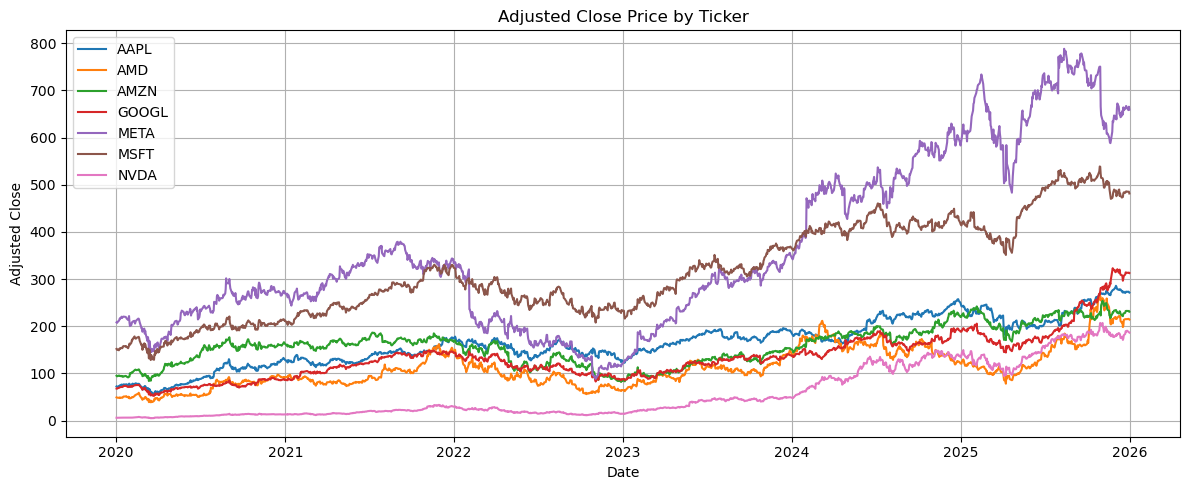

In [40]:

if "adj_close" in df.columns:
    for ticker, g in df.groupby("ticker"):
        plt.plot(g["date"], g["adj_close"], label=ticker)

    plt.title("Adjusted Close Price by Ticker")
    plt.xlabel("Date")
    plt.ylabel("Adjusted Close")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "adjusted_close_by_ticker.png", dpi=150)
    plt.show()
else:
    print("Column 'adj_close' is not available.")


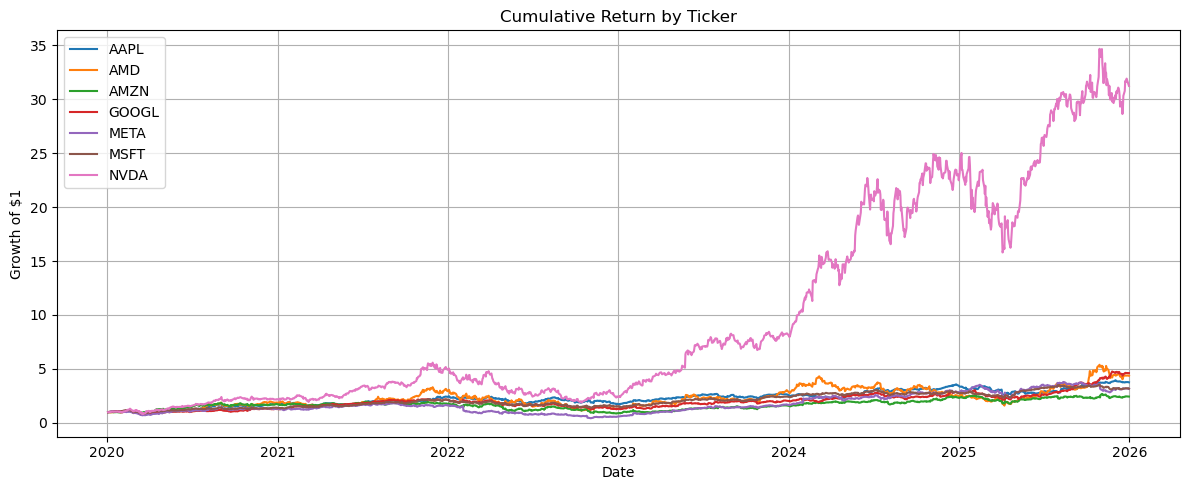

In [41]:

if "return_1d" in df.columns:
    return_df = df.dropna(subset=["return_1d"]).copy()
    return_df["cumulative_return"] = return_df.groupby("ticker")["return_1d"].transform(lambda s: (1 + s).cumprod())

    for ticker, g in return_df.groupby("ticker"):
        plt.plot(g["date"], g["cumulative_return"], label=ticker)

    plt.title("Cumulative Return by Ticker")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "cumulative_return_by_ticker.png", dpi=150)
    plt.show()
else:
    print("Column 'return_1d' is not available.")


In [42]:

if "return_1d" in df.columns:
    return_summary = (
        df.groupby("ticker")["return_1d"]
        .agg(["count", "mean", "std", "min", "median", "max"])
        .reset_index()
    )

    return_summary["annualized_return_approx"] = return_summary["mean"] * 252
    return_summary["annualized_volatility"] = return_summary["std"] * np.sqrt(252)
    return_summary["sharpe_approx"] = (
        return_summary["annualized_return_approx"] / return_summary["annualized_volatility"]
    )

    return_summary.sort_values("sharpe_approx", ascending=False)
else:
    print("Column 'return_1d' is not available.")


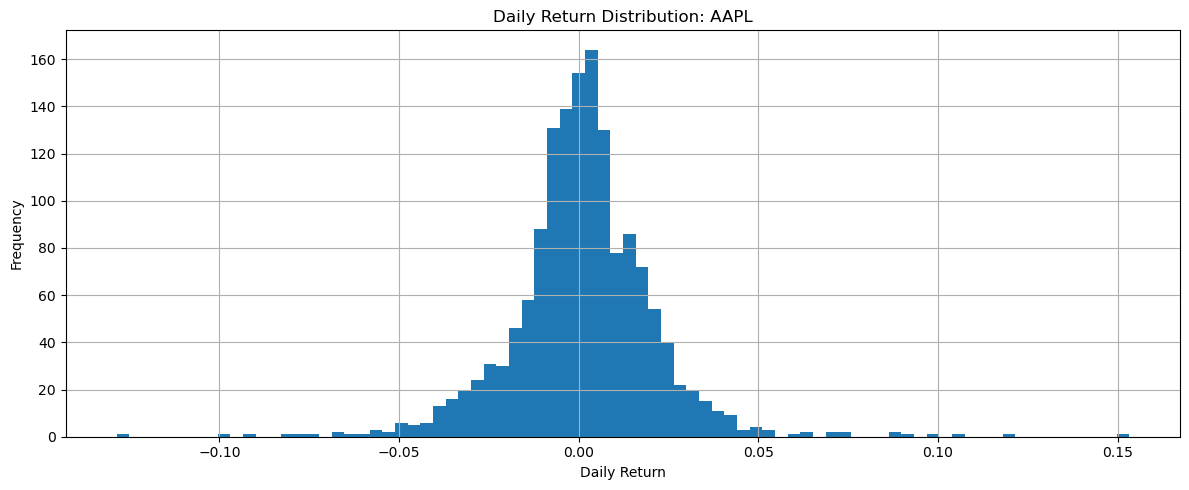

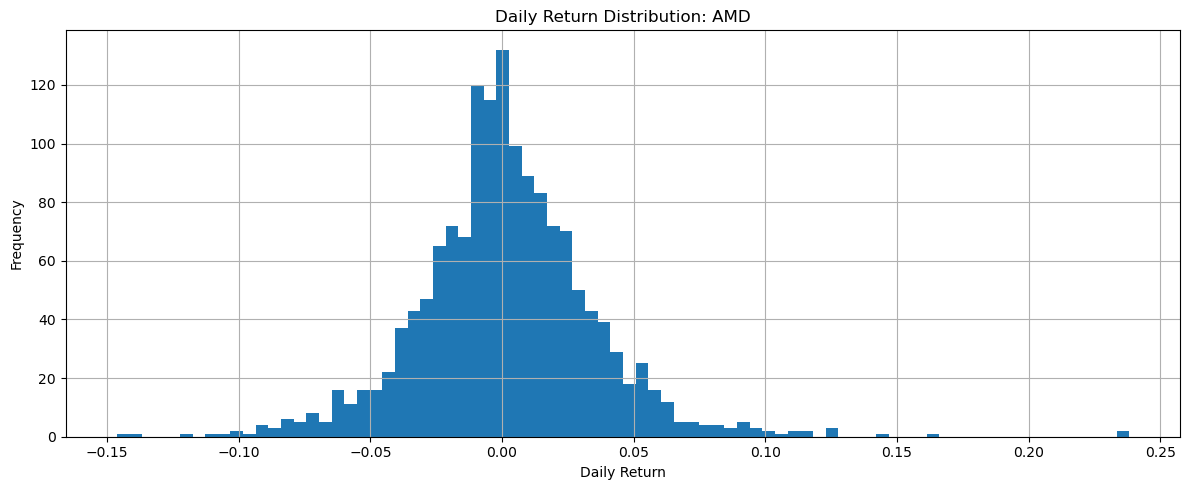

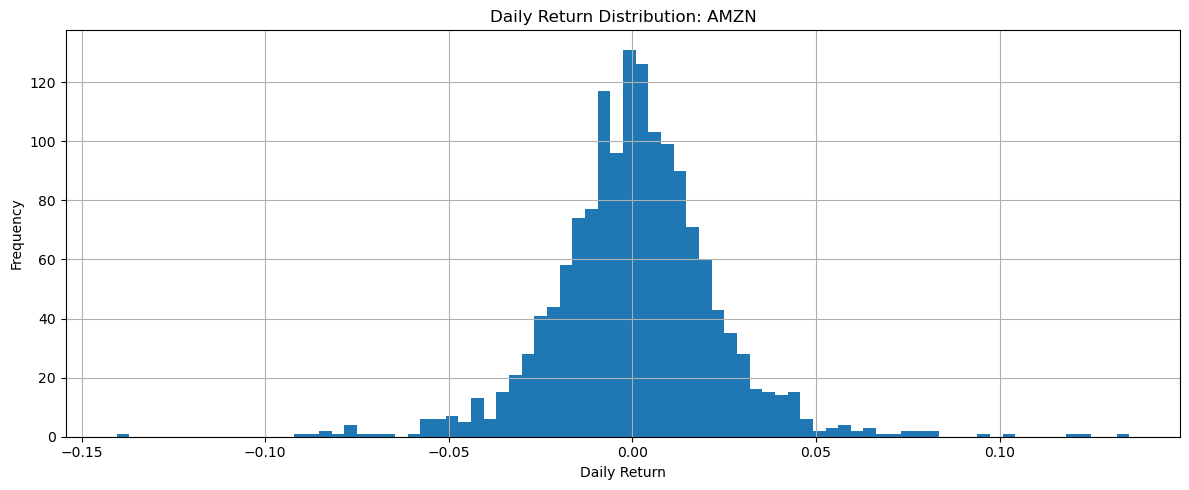

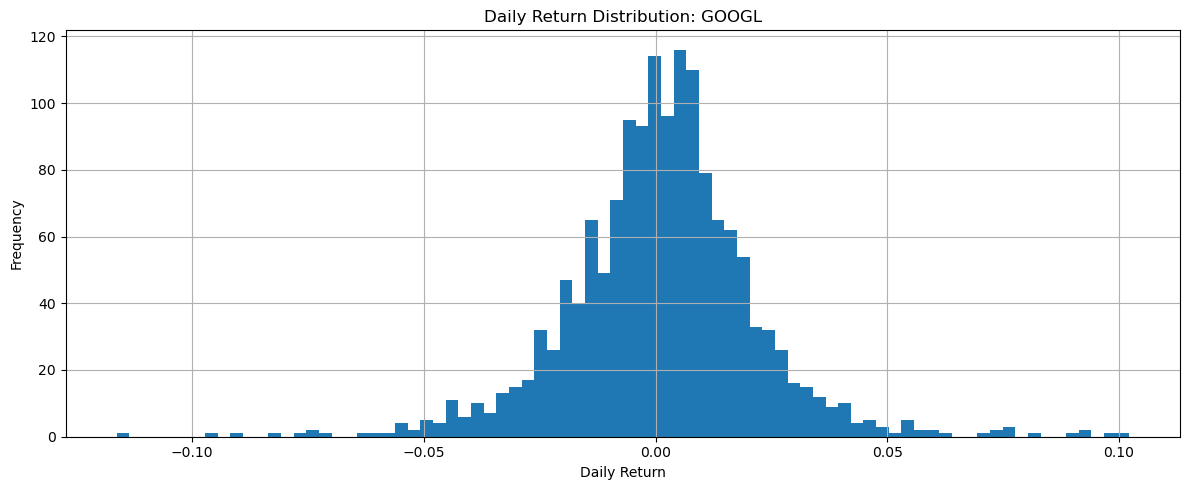

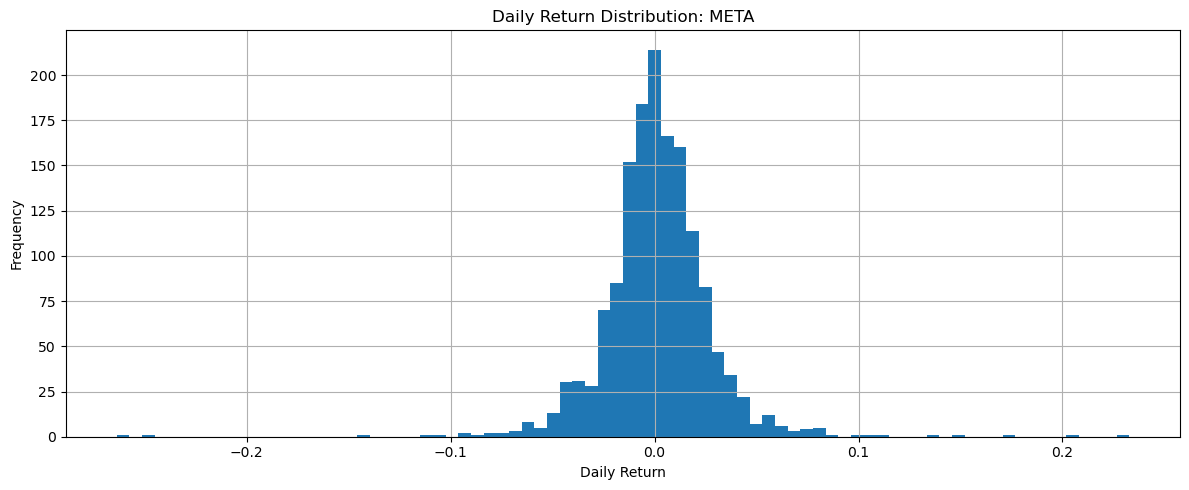

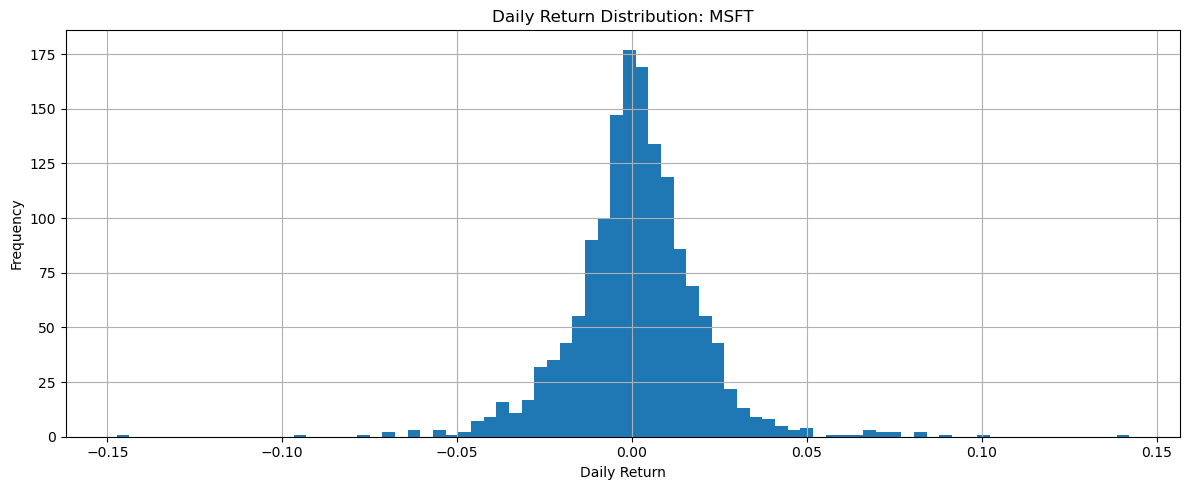

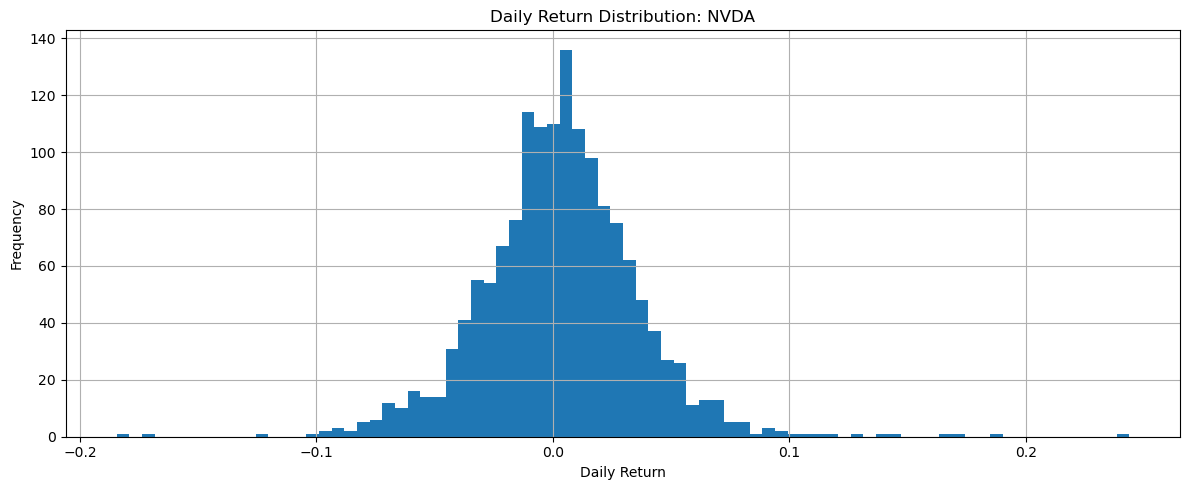

In [43]:

if "return_1d" in df.columns:
    for ticker, g in df.dropna(subset=["return_1d"]).groupby("ticker"):
        plt.figure()
        plt.hist(g["return_1d"], bins=80)
        plt.title(f"Daily Return Distribution: {ticker}")
        plt.xlabel("Daily Return")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"return_distribution_{ticker}.png", dpi=150)
        plt.show()



## 5. Feature Distribution Analysis

This section examines continuous feature distributions.

We are mainly checking:

- whether the values are within a reasonable range;
- whether there are extreme outliers;
- whether a feature is always zero or mostly missing;
- whether the distribution is too skewed for direct use in a neural network model.


In [44]:

continuous_features = [
    "return_1d",
    "trend_5d_return",
    "volume_ma_20",
    "volume_ratio_20",
    "google_trends_ai_interest_raw",
    "sec_ai_intensity_raw",
]

continuous_features = [col for col in continuous_features if col in df.columns]

df[continuous_features].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
return_1d,10549.0,1.374851e-03,2.593701e-02,-2.639010e-01,-6.810523e-02,-3.782951e-02,-1.101841e-02,1.165273e-03,1.380015e-02,4.029266e-02,7.445307e-02,2.436965e-01
trend_5d_return,10521.0,6.742179e-03,5.487537e-02,-3.097807e-01,-1.366996e-01,-7.870583e-02,-2.414775e-02,6.288412e-03,3.640479e-02,9.409369e-02,1.579416e-01,4.362539e-01
volume_ma_20,10528.0,1.006756e+08,1.408922e+08,9.618390e+06,1.174856e+07,1.698563e+07,2.871586e+07,4.717648e+07,8.267017e+07,4.725716e+08,6.200843e+08,7.672618e+08
volume_ratio_20,10528.0,1.005041e+00,3.815154e-01,2.017196e-01,4.846213e-01,5.989910e-01,7.750280e-01,9.188927e-01,1.124685e+00,1.705178e+00,2.460354e+00,5.871968e+00
google_trends_ai_interest_raw,10521.0,1.263977e+01,2.037787e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e+00,1.400000e+01,6.000000e+01,1.000000e+02,1.000000e+02
sec_ai_intensity_raw,10556.0,4.396686e-01,9.834703e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.286589e-01,2.051282e+00,4.000000e+00,9.000000e+00


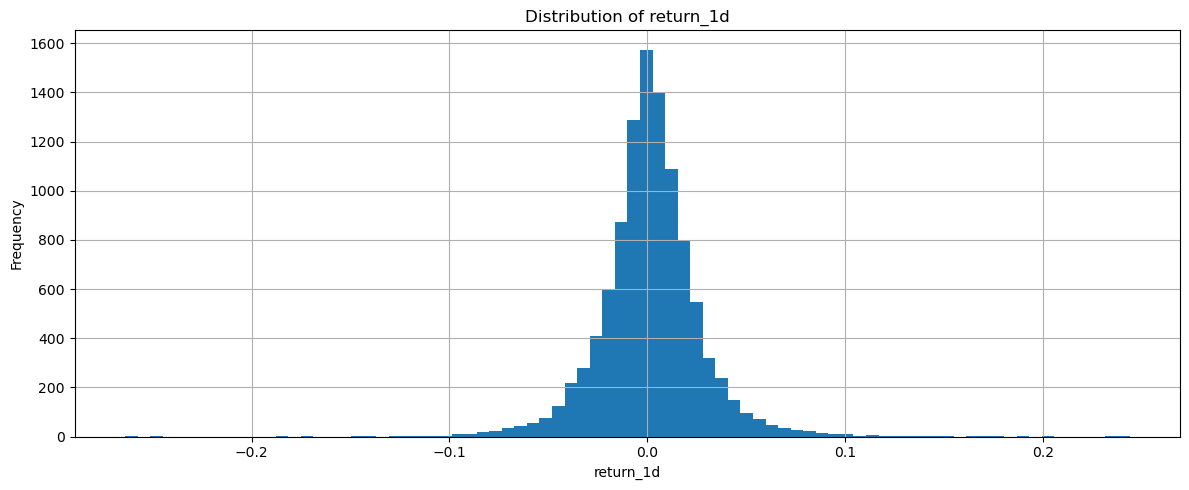

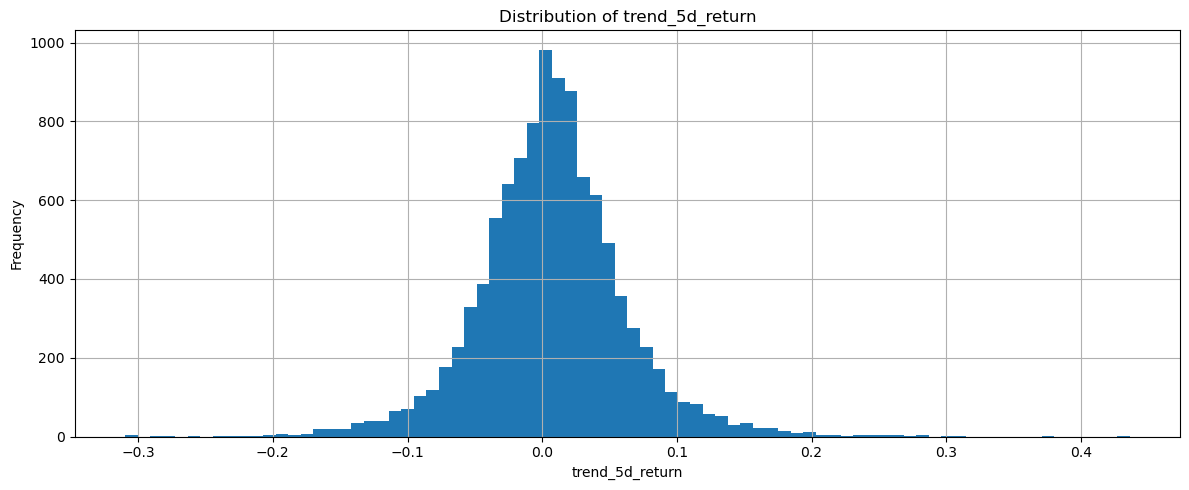

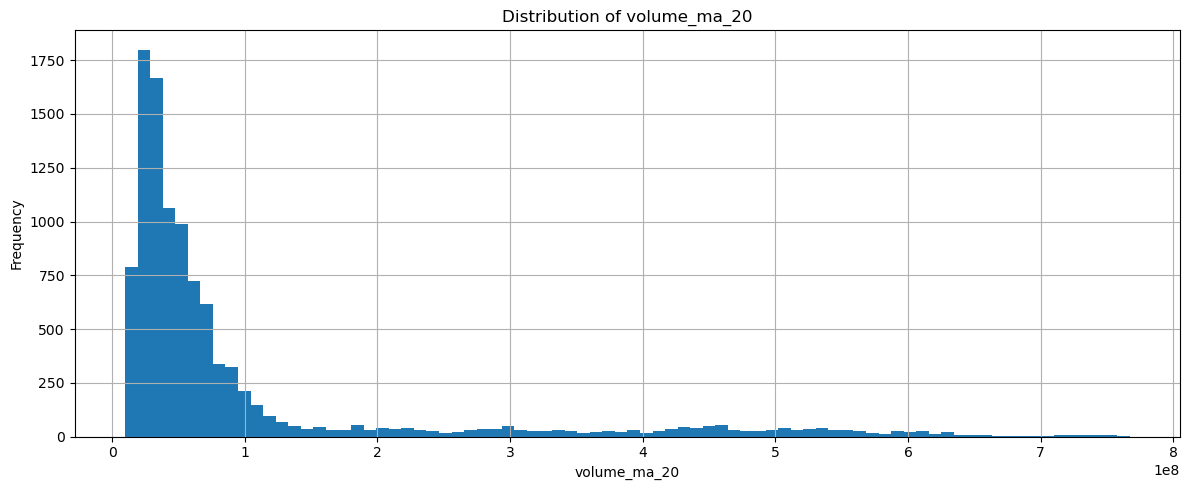

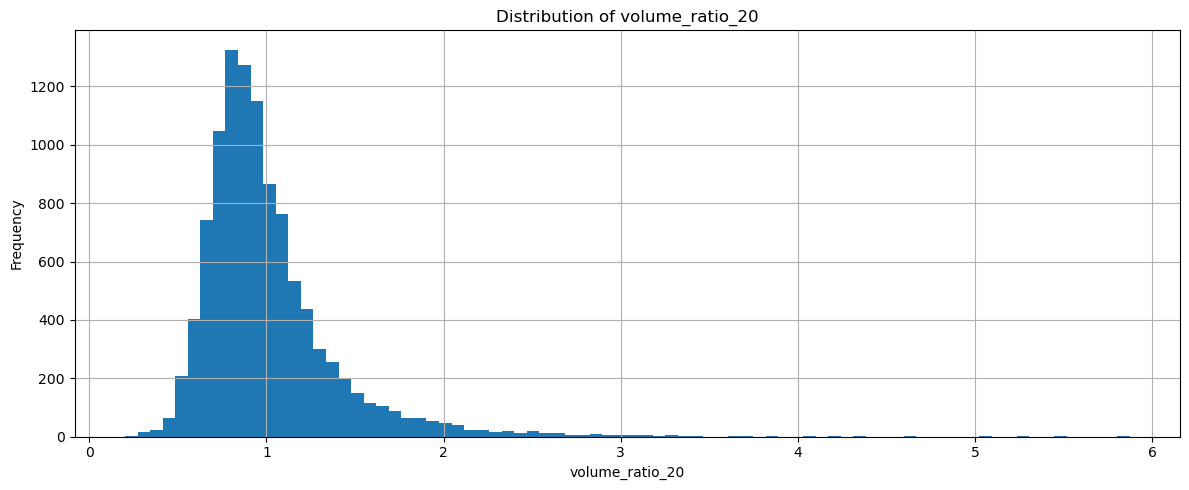

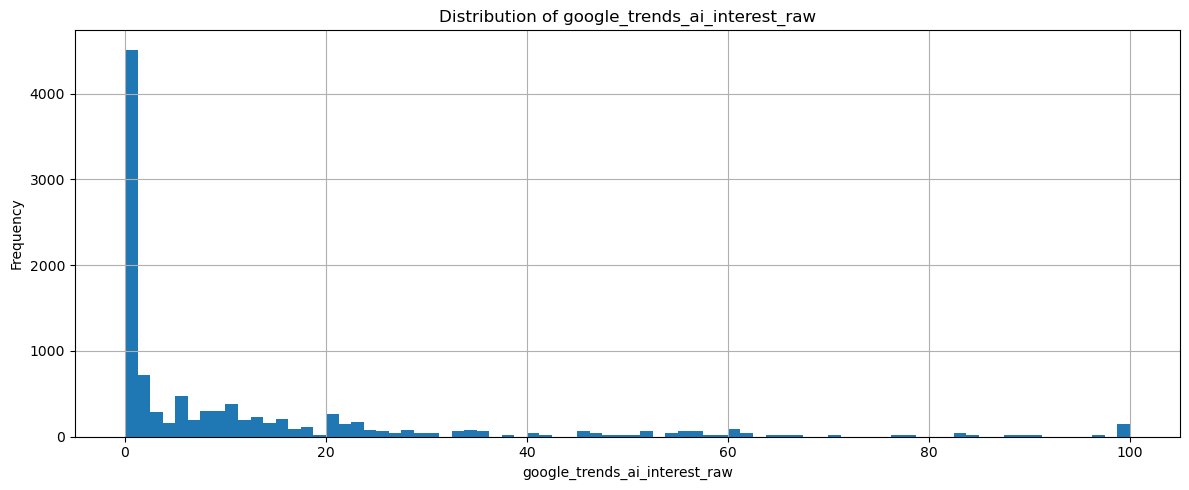

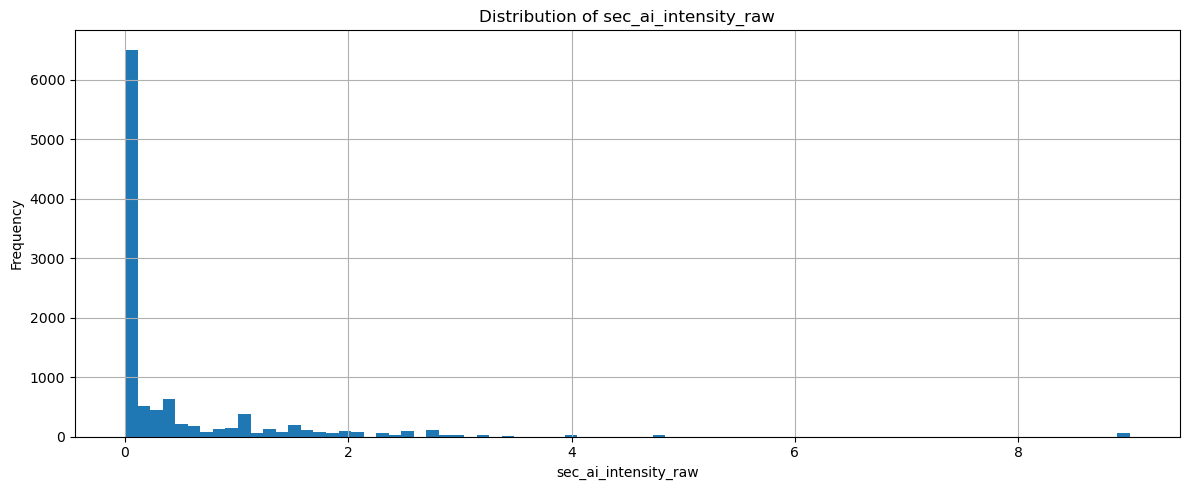

In [45]:

for col in continuous_features:
    plt.figure()
    plt.hist(df[col].dropna(), bins=80)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"distribution_{col}.png", dpi=150)
    plt.show()


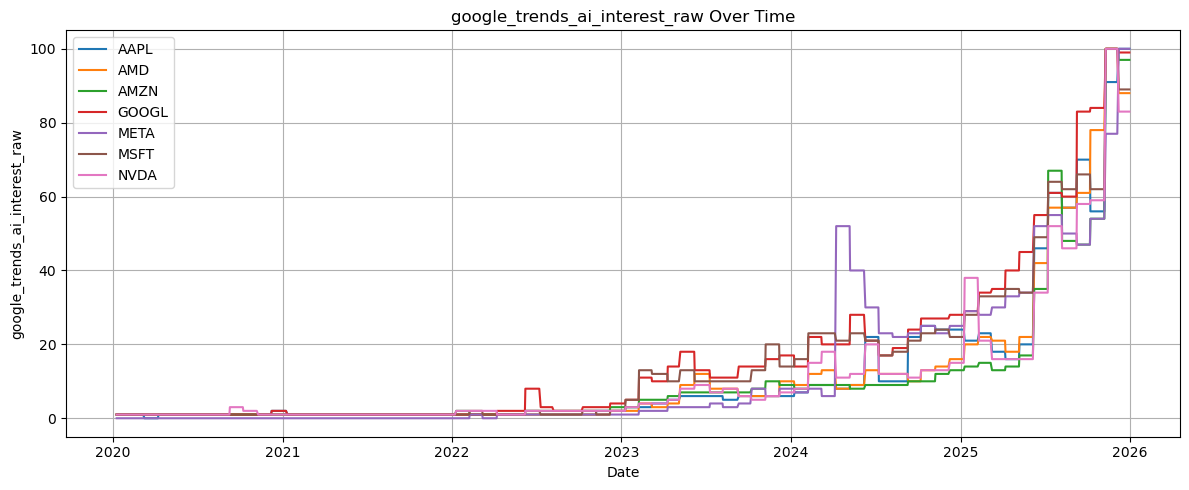

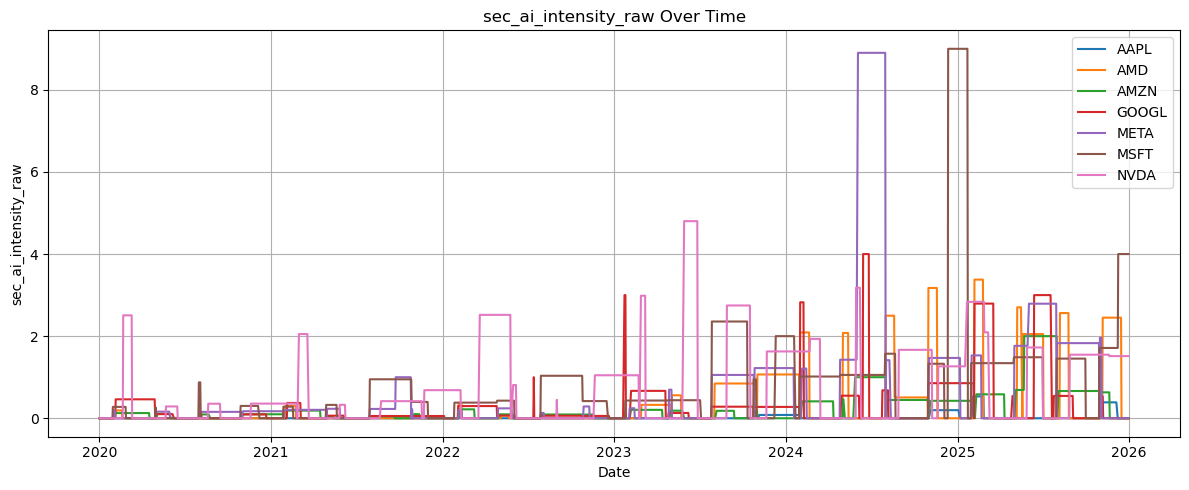

In [46]:

time_series_features = [
    "google_trends_ai_interest_raw",
    "sec_ai_intensity_raw",
]

for col in [c for c in time_series_features if c in df.columns]:
    plt.figure()
    for ticker, g in df.groupby("ticker"):
        plt.plot(g["date"], g[col], label=ticker)

    plt.title(f"{col} Over Time")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"time_series_{col}.png", dpi=150)
    plt.show()



## 6. Bucket and State-Space Analysis

The dataset contains discrete bucket columns that are useful for tabular Q-Learning.

Expected bucket columns:

- `G_bucket`
- `F_bucket`
- `T_bucket`
- `V_bucket`
- `state_without_position`

This section checks:

1. whether bucket distributions are balanced enough;
2. whether the state space is too large or too sparse;
3. how many rare states exist;
4. how many total states will exist after adding the current position.


In [47]:

bucket_cols = ["G_bucket", "F_bucket", "T_bucket", "V_bucket"]
bucket_cols = [col for col in bucket_cols if col in df.columns]

for col in bucket_cols:
    bucket_dist = (
        df[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="count")
    )
    bucket_dist["pct"] = bucket_dist["count"] / len(df)
    print(f"\nDistribution for {col}:")
    display(bucket_dist)



Distribution for G_bucket:


,G_bucket,count,pct
0,high,4813,0.455949
1,low,4550,0.431034
2,medium,1193,0.113016



Distribution for F_bucket:


,F_bucket,count,pct
0,low,5864,0.555513
1,high,2429,0.230106
2,medium,2263,0.214380



Distribution for T_bucket:


,T_bucket,count,pct
0,up,3922,0.371542
1,neutral,3716,0.352027
2,down,2918,0.276430



Distribution for V_bucket:


,V_bucket,count,pct
0,normal,9683,0.917298
1,high,873,0.082702


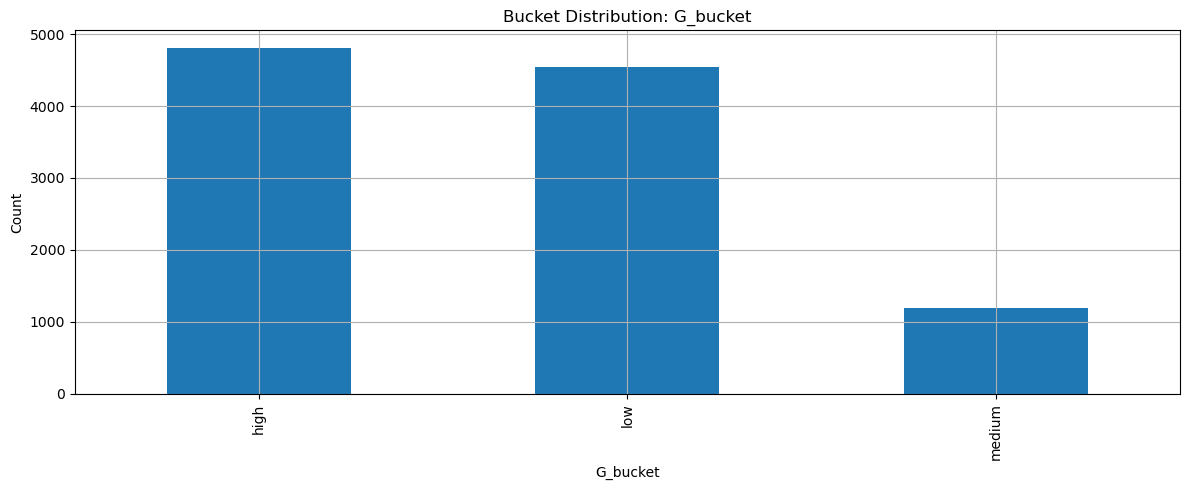

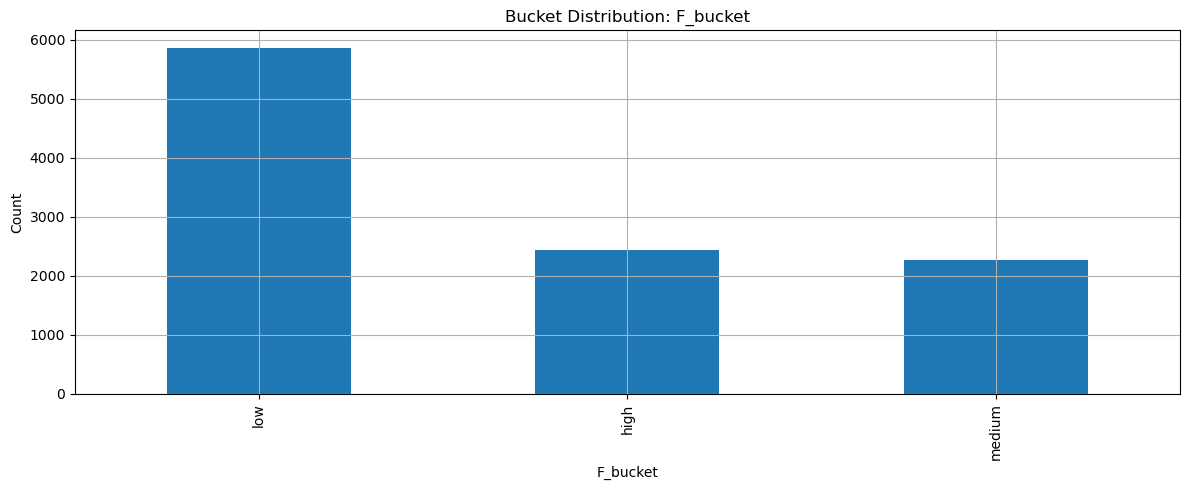

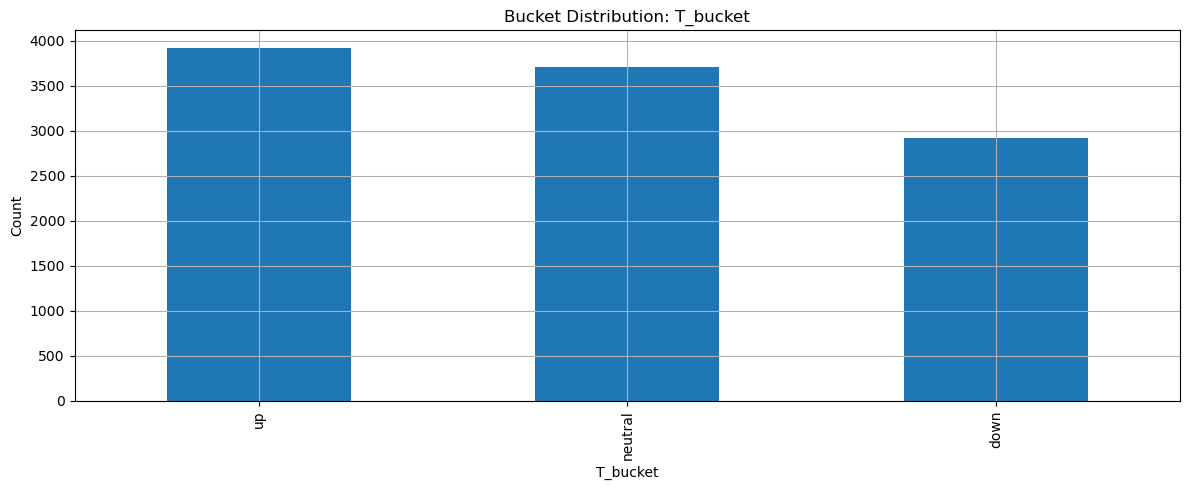

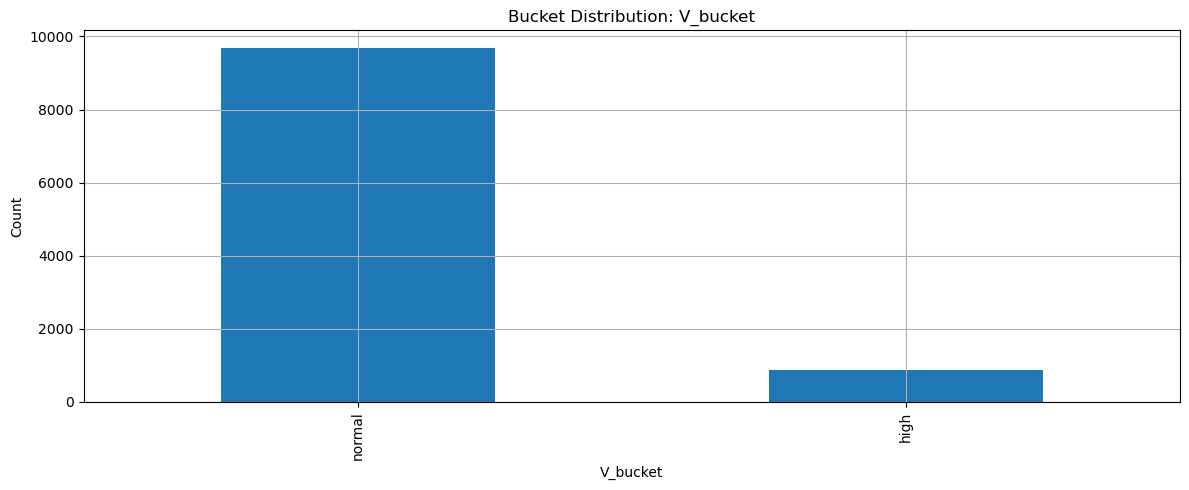

In [48]:

for col in bucket_cols:
    counts = df[col].value_counts(dropna=False)

    plt.figure()
    counts.plot(kind="bar")
    plt.title(f"Bucket Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"bucket_distribution_{col}.png", dpi=150)
    plt.show()


In [49]:

if "state_without_position" in df.columns:
    state_counts = (
        df["state_without_position"]
        .value_counts(dropna=False)
        .rename_axis("state_without_position")
        .reset_index(name="count")
    )
    state_counts["pct"] = state_counts["count"] / len(df)

    print("Number of unique states without position:", state_counts.shape[0])
    print("Theoretical number of states after adding position:", state_counts.shape[0] * 2)

    display(state_counts.head(20))
else:
    print("Column 'state_without_position' is not available.")


Number of unique states without position: 54
Theoretical number of states after adding position: 108


,state_without_position,count,pct
0,low|low|neutral|normal,1002,0.094922
1,low|low|up|normal,984,0.093217
2,high|low|neutral|normal,794,0.075218
3,high|low|up|normal,775,0.073418
4,low|low|down|normal,729,0.069060
5,high|high|neutral|normal,709,0.067166
6,high|high|up|normal,680,0.064418
7,high|low|down|normal,512,0.048503
8,low|medium|neutral|normal,454,0.043009
9,high|high|down|normal,431,0.040830


In [50]:

if "state_without_position" in df.columns:
    rare_state_threshold = 20
    rare_states = state_counts[state_counts["count"] < rare_state_threshold]

    print(f"Number of rare states with count < {rare_state_threshold}:", len(rare_states))
    display(rare_states.head(30))


Number of rare states with count < 20: 14


,state_without_position,count,pct
40,low|medium|neutral|high,19,0.001800
41,medium|low|up|high,15,0.001421
42,high|medium|up|high,15,0.001421
43,low|high|down|high,15,0.001421
44,medium|medium|up|high,11,0.001042
45,high|medium|neutral|high,10,0.000947
46,medium|low|neutral|high,6,0.000568
47,medium|high|down|high,6,0.000568
48,high|medium|down|high,6,0.000568
49,low|high|neutral|high,5,0.000474


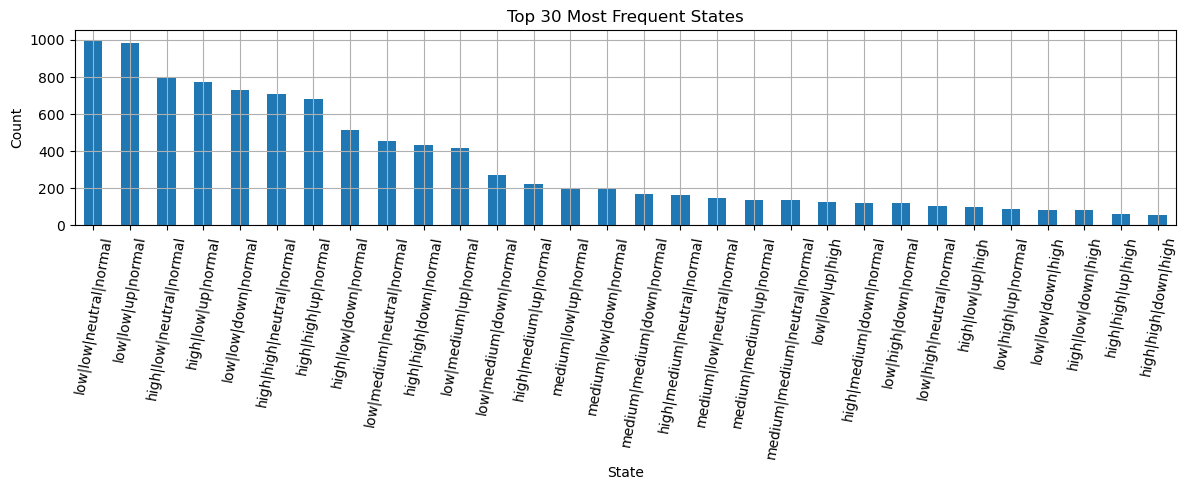

In [51]:

if "state_without_position" in df.columns:
    top_n = 30
    state_counts.head(top_n).plot(
        x="state_without_position",
        y="count",
        kind="bar",
        legend=False,
    )

    plt.title(f"Top {top_n} Most Frequent States")
    plt.xlabel("State")
    plt.ylabel("Count")
    plt.xticks(rotation=80)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "top_state_distribution.png", dpi=150)
    plt.show()



## 7. Next-Day Return and Feature-Return Relationship

For the RL environment, the agent will make a decision at date `t` and receive a reward from the price movement between date `t` and date `t+1`.

Therefore, we compute:

```text
next_return_1d = adj_close[t+1] / adj_close[t] - 1
```

This column is future information relative to date `t`.

It can be used for:

- reward calculation;
- supervised learning labels;
- offline analysis.

It must not be used as an observable state feature.


In [52]:

df_eda = df.copy()

if "adj_close" not in df_eda.columns:
    raise ValueError("Column 'adj_close' is required to compute next_return_1d.")

df_eda["next_return_1d"] = (
    df_eda.groupby("ticker")["adj_close"].shift(-1) / df_eda["adj_close"] - 1
)

print("Missing next_return_1d rows:", df_eda["next_return_1d"].isna().sum())

df_eda[["date", "ticker", "adj_close", "return_1d", "next_return_1d"]].head()


Missing next_return_1d rows: 7


,date,ticker,adj_close,return_1d,next_return_1d
0,2020-01-02,AAPL,72.333878,NaN,-0.009722
1,2020-01-03,AAPL,71.630630,-0.009722,0.007968
2,2020-01-06,AAPL,72.201416,0.007968,-0.004703
3,2020-01-07,AAPL,71.861847,-0.004703,0.016087
4,2020-01-08,AAPL,73.017853,0.016087,0.021241


In [53]:

for col in bucket_cols:
    summary = (
        df_eda.groupby(col)["next_return_1d"]
        .agg(["count", "mean", "std", "median"])
        .sort_values("mean", ascending=False)
    )

    print(f"\nNext-day return by {col}:")
    display(summary)



Next-day return by G_bucket:


,count,mean,std,median
G_bucket,,,,
high,4806,0.001850,0.023445,0.001405
low,4550,0.001272,0.026887,0.001093
medium,1193,-0.000147,0.031227,-0.000095



Next-day return by F_bucket:


,count,mean,std,median
F_bucket,,,,
low,5859,0.001569,0.027907,0.001255
medium,2262,0.001426,0.023937,0.000893
high,2428,0.000859,0.022581,0.001195



Next-day return by T_bucket:


,count,mean,std,median
T_bucket,,,,
neutral,3709,0.001738,0.022191,0.001532
down,2918,0.001669,0.030572,0.001799
up,3922,0.000812,0.025460,0.000416



Next-day return by V_bucket:


,count,mean,std,median
V_bucket,,,,
high,873,0.002875,0.040813,0.001372
normal,9676,0.001239,0.024147,0.001157


In [54]:

if "state_without_position" in df_eda.columns:
    state_return_summary = (
        df_eda.groupby("state_without_position")["next_return_1d"]
        .agg(["count", "mean", "std", "median"])
        .sort_values("mean", ascending=False)
    )

    display(state_return_summary.head(20))


,count,mean,std,median
state_without_position,,,,
medium|low|neutral|high,6,0.038175,0.049032,0.022392
low|high|down|high,15,0.022035,0.033027,0.020630
medium|high|up|high,4,0.021997,0.054341,0.000882
medium|medium|neutral|high,2,0.021574,0.022230,0.021574
low|high|neutral|high,5,0.018850,0.046868,0.012569
high|low|neutral|high,46,0.015073,0.062165,0.005859
medium|medium|up|high,11,0.007453,0.026637,0.011694
high|low|down|high,80,0.006390,0.052085,-0.001035
high|high|neutral|high,33,0.005524,0.034168,0.003497


In [55]:

if "state_without_position" in df_eda.columns:
    minimum_state_count = 50
    state_return_summary_filtered = state_return_summary[state_return_summary["count"] >= minimum_state_count]

    print(f"States with at least {minimum_state_count} observations:", len(state_return_summary_filtered))
    display(state_return_summary_filtered.sort_values("mean", ascending=False).head(20))


States with at least 50 observations: 30


,count,mean,std,median
state_without_position,,,,
high|low|down|high,80,0.006390,0.052085,-0.001035
high|medium|down|normal,122,0.003981,0.029566,0.003357
low|low|down|high,82,0.003134,0.045807,0.003450
high|high|down|high,56,0.002663,0.033208,-0.000067
high|medium|neutral|normal,162,0.002604,0.020033,0.001655
high|medium|up|normal,224,0.002574,0.021198,0.001415
high|low|down|normal,512,0.002280,0.026445,0.002547
low|medium|up|normal,415,0.002230,0.023902,0.000825
low|medium|down|normal,269,0.002229,0.026379,0.003210



## 8. Correlation Analysis

This section examines correlations between continuous features and `next_return_1d`.

In financial datasets, linear correlations with future returns are often weak. A weak correlation does not necessarily mean a feature is useless, but it helps identify obvious issues, redundancy, or suspicious features.


In [56]:

corr_cols = [
    "return_1d",
    "trend_5d_return",
    "volume_ratio_20",
    "google_trends_ai_interest_raw",
    "sec_ai_intensity_raw",
    "next_return_1d",
]

corr_cols = [col for col in corr_cols if col in df_eda.columns]

corr = df_eda[corr_cols].corr()
corr


,return_1d,trend_5d_return,volume_ratio_20,google_trends_ai_interest_raw,sec_ai_intensity_raw,next_return_1d
return_1d,1.000000,0.426138,0.019460,0.003919,-0.008341,-0.078256
trend_5d_return,0.426138,1.000000,-0.018083,0.012120,-0.009290,-0.035665
volume_ratio_20,0.019460,-0.018083,1.000000,-0.023546,-0.014624,0.010067
google_trends_ai_interest_raw,0.003919,0.012120,-0.023546,1.000000,0.264712,0.002806
sec_ai_intensity_raw,-0.008341,-0.009290,-0.014624,0.264712,1.000000,-0.007512
next_return_1d,-0.078256,-0.035665,0.010067,0.002806,-0.007512,1.000000


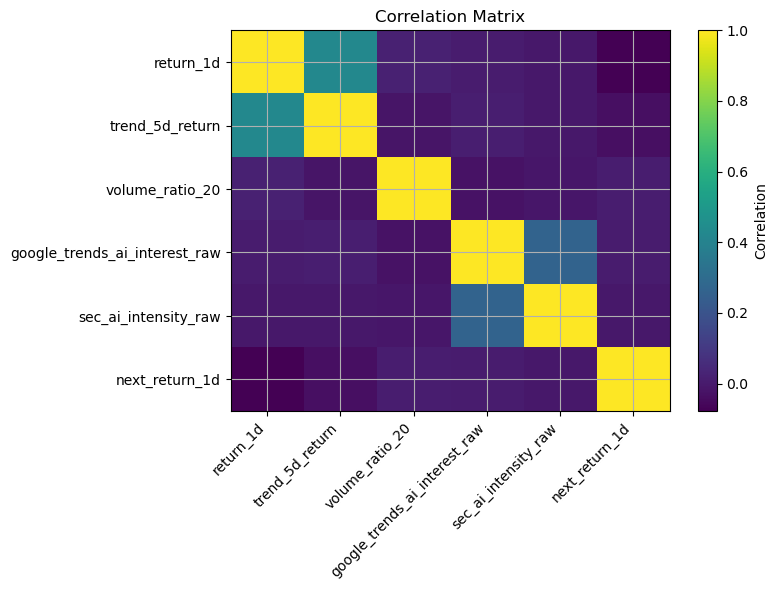

In [57]:

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Correlation")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_matrix.png", dpi=150)
plt.show()


## 9. Train / Test Split

For the current preliminary RL experiment, we use a simple train/test split:

- **Train:** dates up to and including `2023-12-31`
- **Test:** dates on or after `2024-01-01`

In [58]:
TRAIN_END = pd.Timestamp("2023-12-31")
TEST_START = pd.Timestamp("2024-01-01")


def assign_split(date):
    """Chronological train/test split for financial time series."""
    if pd.Timestamp(date) <= TRAIN_END:
        return "train"
    return "test"


df_eda["split"] = df_eda["date"].apply(assign_split)

split_summary = (
    df_eda.groupby(["split", "ticker"])
    .agg(
        rows=("date", "size"),
        start_date=("date", "min"),
        end_date=("date", "max"),
    )
    .reset_index()
)

split_summary


,split,ticker,rows,start_date,end_date
0,test,AAPL,502,2024-01-02,2025-12-31
1,test,AMD,502,2024-01-02,2025-12-31
2,test,AMZN,502,2024-01-02,2025-12-31
3,test,GOOGL,502,2024-01-02,2025-12-31
4,test,META,502,2024-01-02,2025-12-31
5,test,MSFT,502,2024-01-02,2025-12-31
6,test,NVDA,502,2024-01-02,2025-12-31
7,train,AAPL,1006,2020-01-02,2023-12-29
8,train,AMD,1006,2020-01-02,2023-12-29
9,train,AMZN,1006,2020-01-02,2023-12-29


In [59]:
print(df_eda["split"].value_counts())

split_check = (
    df_eda.groupby("split")
    .agg(
        rows=("date", "size"),
        start_date=("date", "min"),
        end_date=("date", "max"),
        tickers=("ticker", "nunique"),
    )
)

split_check


split
train    7042
test     3514
Name: count, dtype: int64


,rows,start_date,end_date,tickers
split,,,,
test,3514,2024-01-02,2025-12-31,7
train,7042,2020-01-02,2023-12-29,7


## 10. Build a Clean RL-Ready Dataset

This section creates the canonical dataset consumed by `environment.py`:

```text
data/processed/rl_dataset.csv
```

The cleaned dataset keeps:

- date, ticker, OHLCV, adjusted close;
- observable market and AI-signal features for analysis/debugging;
- discrete bucket columns and `state_without_position`;
- `next_return_1d` for reward calculation;
- chronological split labels: `train` or `test`.

For the 2-action environment, the **minimum required columns** are:

```text
date
ticker
state_without_position
next_return_1d
split
```

Rows missing any of these minimum required columns are removed.


In [60]:
base_cols = [
    "date",
    "ticker",
    "open",
    "high",
    "low",
    "close",
    "adj_close",
    "volume",
]

observable_feature_cols = [
    "return_1d",
    "trend_5d_return",
    "volume_ma_20",
    "volume_ratio_20",
    "google_trends_ai_interest_raw",
    "sec_ai_intensity_raw",
    "G_bucket",
    "F_bucket",
    "T_bucket",
    "V_bucket",
    "state_without_position",
]

label_and_metadata_cols = [
    "next_return_1d",
    "split",
]

available_cols = [
    col
    for col in base_cols + observable_feature_cols + label_and_metadata_cols
    if col in df_eda.columns
]

rl_ready = df_eda[available_cols].copy()

# The environment only requires these columns.
# Continuous features are kept for debugging and analysis, but the environment
# does not use them to rebuild states.
required_non_missing_cols = [
    "date",
    "ticker",
    "state_without_position",
    "next_return_1d",
    "split",
]

missing_required = [col for col in required_non_missing_cols if col not in rl_ready.columns]
if missing_required:
    raise ValueError(f"Missing required RL columns: {missing_required}")

rl_ready_clean = rl_ready.dropna(subset=required_non_missing_cols).copy()
rl_ready_clean = rl_ready_clean.sort_values(["ticker", "date"]).reset_index(drop=True)

# Normalize split labels so environment.py can match them safely.
rl_ready_clean["split"] = rl_ready_clean["split"].astype(str).str.lower().str.strip()

# Safety check: next_return_1d is a reward/label column, not an observable state feature.
state_contains_future_label = rl_ready_clean["state_without_position"].astype(str).str.contains(
    "next_return", case=False, regex=False
).any()

if state_contains_future_label:
    raise ValueError("state_without_position appears to contain next_return information. This is leakage.")

print("Shape before cleaning:", rl_ready.shape)
print("Shape after cleaning:", rl_ready_clean.shape)
print("Rows dropped:", len(rl_ready) - len(rl_ready_clean))
print("Splits:", sorted(rl_ready_clean["split"].unique()))

rl_ready_clean.head()


Shape before cleaning: (10556, 21)
Shape after cleaning: (10549, 21)
Rows dropped: 7
Splits: ['test', 'train']


,date,ticker,open,high,low,close,adj_close,volume,return_1d,trend_5d_return,volume_ma_20,volume_ratio_20,google_trends_ai_interest_raw,sec_ai_intensity_raw,G_bucket,F_bucket,T_bucket,V_bucket,state_without_position,next_return_1d,split
0,2020-01-02,AAPL,74.059998,75.150002,73.797501,75.087502,72.333878,135480400,NaN,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal,-0.009722,train
1,2020-01-03,AAPL,74.287498,75.144997,74.125000,74.357498,71.630630,146322800,-0.009722,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal,0.007968,train
2,2020-01-06,AAPL,73.447502,74.989998,73.187500,74.949997,72.201416,118387200,0.007968,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal,-0.004703,train
3,2020-01-07,AAPL,74.959999,75.224998,74.370003,74.597504,71.861847,108872000,-0.004703,NaN,NaN,NaN,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal,0.016087,train
4,2020-01-08,AAPL,74.290001,76.110001,74.290001,75.797501,73.017853,132079200,0.016087,NaN,128228320.0,1.030031,NaN,0.0,low,low,neutral,normal,low|low|neutral|normal,0.021241,train


In [61]:
n_states = (
    rl_ready_clean["state_without_position"].nunique()
    if "state_without_position" in rl_ready_clean.columns
    else np.nan
)

final_quality_checks = {
    "rows": len(rl_ready_clean),
    "tickers": rl_ready_clean["ticker"].nunique() if "ticker" in rl_ready_clean.columns else np.nan,
    "start_date": rl_ready_clean["date"].min() if "date" in rl_ready_clean.columns else np.nan,
    "end_date": rl_ready_clean["date"].max() if "date" in rl_ready_clean.columns else np.nan,
    "duplicated_ticker_date": (
        rl_ready_clean.duplicated(["ticker", "date"]).sum()
        if {"ticker", "date"}.issubset(rl_ready_clean.columns)
        else np.nan
    ),
    "total_missing_values": rl_ready_clean.isna().sum().sum(),
    "unique_states": n_states,
    "q_values_2_action": n_states * 2 if pd.notna(n_states) else np.nan,
    "train_rows": int((rl_ready_clean["split"] == "train").sum()) if "split" in rl_ready_clean.columns else np.nan,
    "test_rows": int((rl_ready_clean["split"] == "test").sum()) if "split" in rl_ready_clean.columns else np.nan,
}

pd.Series(final_quality_checks).to_frame("value")


,value
rows,10549
tickers,7
start_date,2020-01-02 00:00:00
end_date,2025-12-30 00:00:00
duplicated_ticker_date,0
total_missing_values,133
unique_states,54
q_values_2_action,108
train_rows,7042
test_rows,3507


In [62]:
output_path = Path("../data/processed/rl_dataset.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
rl_ready_clean.to_csv(output_path, index=False)

eda_copy_path = OUTPUT_DIR / "rl_dataset.csv"
rl_ready_clean.to_csv(eda_copy_path, index=False)

print("Saved canonical RL dataset to:", output_path)
print("Saved EDA copy to:", eda_copy_path)


Saved canonical RL dataset to: ../data/processed/rl_dataset.csv
Saved EDA copy to: outputs/eda/rl_dataset.csv


## 11. Feature Sets for RL

### Tabular Q-Learning: 2-Action Version

For the current rescue version of the project, use this discrete state representation:

```text
state = state_without_position
```

The action directly selects the next-period position:

```text
0 = FLAT
1 = LONG
```

Reward:

```text
reward[t] = action[t] * next_return_1d[t]
```

Interpretation:

- if `action = 0`, the agent holds cash for the next period and receives reward `0`;
- if `action = 1`, the agent holds the stock for the next period and receives `next_return_1d[t]`.